# QHARM Barrier Shift Analysis

Objective: quantify how the quasi-harmonic free-energy update changes the TS barriers and reaction free energies relative to the released database.

Inputs are generated by `revision_quasi_harmonic_free_energy.ipynb` and the released TS CSV:

- `output/jupyter-notebook/quasi_harmonic_free_energy_update.csv`
- `output/jupyter-notebook/quasi_harmonic_reaction_energy_summary.csv`
- `Data/TS/Borane_all.csv`

## Plan

- Merge original database barriers with QHARM barriers by reaction key.
- Compute R2, MAE, RMSE, bias, and linear-fit metrics.
- Separate the database-level comparison from the pure AaronTools RRHO-to-QHARM comparison.
- Save publication-ready scatter and distribution plots.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from DFTStructureGenerator.thermochemistry import database_path, load_reaction_dataset, load_structure_thermochemistry

HARTREE_TO_KCAL = 627.509474
OUTDIR = Path("output/jupyter-notebook")
FIGURE_DIR = Path("Figure")
# Thermochemistry switch: QHARM is the revised default.
USE_QHARM = True
DB_PATH = database_path(USE_QHARM)
SELECTED_BARRIER_COLUMN = "deltaGa_qharm(kcal/mol)" if USE_QHARM else "deltaGa(kcal/mol)"
SELECTED_REACTION_ENERGY_COLUMN = "deltaG_qharm(kcal/mol)" if USE_QHARM else "deltaG(kcal/mol)"
QHARM_DB_PATH = database_path(True)  # auxiliary RRHO/QRRHO variants only exist in the updated DB
OUTDIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

## Load Original and QHARM Tables

In [2]:
ts_csv = load_reaction_dataset("Data/TS/Borane_all.csv", use_qharm=False)
ts_csv["key"] = ts_csv.apply(
    lambda r: f"B_{int(r['B_Index']):05}_LB_{int(r['N_Index']):05}_Cl_{int(r['Cl_Index']):05}",
    axis=1,
)
orig_ts = ts_csv[["key", "deltaGa(kcal/mol)", "deltaG(kcal/mol)"]].rename(
    columns={
        "deltaGa(kcal/mol)": "barrier_kcal",
        "deltaG(kcal/mol)": "delta_g_rxn_kcal",
    }
)

selected_ts = load_reaction_dataset(
    "Data/TS/Borane_all.csv", use_qharm=USE_QHARM, db_path=DB_PATH
)
selected_ts["key"] = selected_ts.apply(
    lambda r: f"B_{int(r['B_Index']):05}_LB_{int(r['N_Index']):05}_Cl_{int(r['Cl_Index']):05}",
    axis=1,
)
qh = selected_ts[["key", SELECTED_BARRIER_COLUMN, SELECTED_REACTION_ENERGY_COLUMN]].rename(
    columns={
        SELECTED_BARRIER_COLUMN: "barrier_qharm_kcal",
        SELECTED_REACTION_ENERGY_COLUMN: "delta_g_rxn_qharm_kcal",
    }
)
thermo = load_structure_thermochemistry(QHARM_DB_PATH)

print("Original TS rows:", len(orig_ts))
print("QHARM TS rows:", len(qh))
display(qh[["barrier_qharm_kcal", "delta_g_rxn_qharm_kcal"]].describe())

Original TS rows: 9237
QHARM TS rows: 9237


,barrier_qharm_kcal,delta_g_rxn_qharm_kcal
count,9237.000000,9237.000000
mean,15.426717,-19.750904
std,5.178058,10.201556
min,-3.385036,-64.300651
25%,11.724975,-26.918227
50%,15.345378,-18.836923
75%,18.972021,-11.577965
max,40.354847,-0.041187


## Rebuild AaronTools RRHO/QRRHO Reaction Summaries

In [3]:
def build_summary(gibbs_col, prefix):
    ok = thermo.loc[thermo["status"].eq("ok")].copy()
    g = ok.set_index("key")[gibbs_col].to_dict()
    rows = []
    for key in sorted(ok.loc[ok["category"].eq("ts"), "key"]):
        parts = key.split("_")
        b5, l5, c5 = parts[1], parts[3], parts[5]
        r_complex = f"B_{b5}_LB_{l5}_r"
        r_cl = f"Cl_{c5}_r"
        p_complex = f"B_{b5}_LB_{l5}_p"
        p_rad = f"Cl_{c5}_p"
        barrier = np.nan
        rxn = np.nan
        if all(k in g for k in [key, r_complex, r_cl]):
            barrier = (g[key] - g[r_complex] - g[r_cl]) * HARTREE_TO_KCAL
        if all(k in g for k in [p_complex, p_rad, r_complex, r_cl]):
            rxn = (g[p_complex] + g[p_rad] - g[r_complex] - g[r_cl]) * HARTREE_TO_KCAL
        rows.append({
            "key": key,
            f"barrier_{prefix}_kcal": barrier,
            f"delta_g_rxn_{prefix}_kcal": rxn,
        })
    return pd.DataFrame(rows)


rrho = build_summary("gibbs_rrho_hartree", "aarontools_rrho")
qrrho = build_summary("gibbs_qrrho_hartree", "qrrho")
full_qrrho = build_summary("gibbs_full_qrrho_hartree", "full_qrrho")

## Merge and Compute Delta Columns

In [4]:
comparison = (
    orig_ts
    .merge(qh, on="key")
    .merge(rrho, on="key")
    .merge(qrrho, on="key")
    .merge(full_qrrho, on="key")
)
comparison["delta_barrier_qharm_vs_original"] = comparison["barrier_qharm_kcal"] - comparison["barrier_kcal"]
comparison["delta_barrier_qharm_vs_at_rrho"] = comparison["barrier_qharm_kcal"] - comparison["barrier_aarontools_rrho_kcal"]
comparison["delta_barrier_at_rrho_vs_original"] = comparison["barrier_aarontools_rrho_kcal"] - comparison["barrier_kcal"]
comparison["delta_rxn_qharm_vs_original"] = comparison["delta_g_rxn_qharm_kcal"] - comparison["delta_g_rxn_kcal"]

comparison.to_csv(OUTDIR / "qh_barrier_comparison.csv", index=False)
display(comparison.head())
display(comparison[[
    "delta_barrier_qharm_vs_original",
    "delta_barrier_qharm_vs_at_rrho",
    "delta_barrier_at_rrho_vs_original",
    "delta_rxn_qharm_vs_original",
]].describe())

,key,barrier_kcal,delta_g_rxn_kcal,barrier_qharm_kcal,delta_g_rxn_qharm_kcal,reactant_complex_key,reactant_cl_key,product_complex_key,product_c_radical_key,barrier_aarontools_rrho_kcal,delta_g_rxn_aarontools_rrho_kcal,barrier_qrrho_kcal,delta_g_rxn_qrrho_kcal,barrier_full_qrrho_kcal,delta_g_rxn_full_qrrho_kcal,delta_barrier_qharm_vs_original,delta_barrier_qharm_vs_at_rrho,delta_barrier_at_rrho_vs_original,delta_rxn_qharm_vs_original
0,B_00388_LB_00000_Cl_00500,15.690129,-33.510445,14.545776,-31.954293,B_00388_LB_00000_r,Cl_00500_r,B_00388_LB_00000_p,Cl_00500_p,11.740261,-31.828386,13.907325,-31.799545,12.552275,-31.929472,-1.144353,2.805516,-3.949868,1.556152
1,B_00388_LB_00001_Cl_00466,9.890297,-41.280903,9.404659,-43.522449,B_00388_LB_00001_r,Cl_00466_r,B_00388_LB_00001_p,Cl_00466_p,7.193915,-43.537096,8.986063,-43.539502,7.744316,-43.526392,-0.485639,2.210743,-2.696382,-2.241546
2,B_00388_LB_00001_Cl_00474,12.493770,-23.956318,8.268203,-25.620507,B_00388_LB_00001_r,Cl_00474_r,B_00388_LB_00001_p,Cl_00474_p,6.440180,-25.510839,7.950991,-25.571051,6.842782,-25.563777,-4.225567,1.828023,-6.053590,-1.664188
3,B_00388_LB_00001_Cl_00475,14.914297,-28.161071,11.353407,-29.443907,B_00388_LB_00001_r,Cl_00475_r,B_00388_LB_00001_p,Cl_00475_p,9.368439,-29.443907,10.939101,-29.377085,9.858047,-29.517688,-3.560890,1.984967,-5.545858,-1.282837
4,B_00388_LB_00001_Cl_00476,14.312536,-38.631535,12.129193,-40.008991,B_00388_LB_00001_r,Cl_00476_r,B_00388_LB_00001_p,Cl_00476_p,9.717499,-40.008991,11.618986,-39.953295,10.395554,-40.054031,-2.183343,2.411694,-4.595037,-1.377456


,delta_barrier_qharm_vs_original,delta_barrier_qharm_vs_at_rrho,delta_barrier_at_rrho_vs_original,delta_rxn_qharm_vs_original
count,9237.000000,9237.000000,9237.000000,9237.000000
mean,-5.578991,2.297975,-7.876967,0.381306
std,2.631185,0.859062,2.357310,1.872835
min,-36.303602,-1.134580,-38.542867,-24.656695
25%,-7.440403,1.721153,-9.607324,-0.860113
50%,-5.455192,2.269423,-7.743287,0.339647
75%,-3.679748,2.842936,-6.179595,1.555971
max,6.875007,5.478521,4.110353,12.565083


## Metrics

In [5]:
def metrics(df, x, y, label):
    d = df[[x, y]].dropna()
    y_true = d[x].to_numpy()
    y_pred = d[y].to_numpy()
    diff = y_pred - y_true
    slope, intercept, pearson_r, pearson_p, stderr = stats.linregress(y_true, y_pred)
    return {
        "comparison": label,
        "n": len(d),
        "x": x,
        "y": y,
        "R2_identity": r2_score(y_true, y_pred),
        "R2_linear_fit": pearson_r ** 2,
        "MAE_kcal_mol": mean_absolute_error(y_true, y_pred),
        "RMSE_kcal_mol": mean_squared_error(y_true, y_pred) ** 0.5,
        "mean_delta_kcal_mol": diff.mean(),
        "median_delta_kcal_mol": np.median(diff),
        "std_delta_kcal_mol": diff.std(ddof=1),
        "min_delta_kcal_mol": diff.min(),
        "max_delta_kcal_mol": diff.max(),
        "pearson_r": pearson_r,
        "spearman_r": stats.spearmanr(y_true, y_pred).statistic,
        "linear_slope": slope,
        "linear_intercept": intercept,
    }


metrics_df = pd.DataFrame([
    metrics(comparison, "barrier_kcal", "barrier_qharm_kcal", "Barrier: original DB -> QHARM"),
    metrics(comparison, "barrier_aarontools_rrho_kcal", "barrier_qharm_kcal", "Barrier: AaronTools RRHO -> QHARM"),
    metrics(comparison, "barrier_kcal", "barrier_aarontools_rrho_kcal", "Barrier: original DB -> AaronTools RRHO"),
    metrics(comparison, "delta_g_rxn_kcal", "delta_g_rxn_qharm_kcal", "Reaction dG: original DB -> QHARM"),
])
metrics_df.to_csv(OUTDIR / "qh_barrier_metrics.csv", index=False)
display(metrics_df)

,comparison,n,x,y,R2_identity,R2_linear_fit,MAE_kcal_mol,RMSE_kcal_mol,mean_delta_kcal_mol,median_delta_kcal_mol,std_delta_kcal_mol,min_delta_kcal_mol,max_delta_kcal_mol,pearson_r,spearman_r,linear_slope,linear_intercept
0,Barrier: original DB -> QHARM,9237,barrier_kcal,barrier_qharm_kcal,0.055065,0.837962,5.597352,6.168268,-5.578991,-5.455192,2.631185,-36.303602,6.875007,0.915403,0.917900,0.746953,-0.263565
1,Barrier: AaronTools RRHO -> QHARM,9237,barrier_aarontools_rrho_kcal,barrier_qharm_kcal,0.773095,0.972548,2.300028,2.453283,2.297975,2.269423,0.859062,-1.134580,5.478521,0.986178,0.985235,0.991455,2.410156
2,Barrier: original DB -> AaronTools RRHO,9237,barrier_kcal,barrier_aarontools_rrho_kcal,-0.678962,0.877682,7.878346,8.222099,-7.876967,-7.743287,2.357310,-38.542867,4.110353,0.936847,0.939503,0.760383,-2.843634
3,Reaction dG: original DB -> QHARM,9237,delta_g_rxn_kcal,delta_g_rxn_qharm_kcal,0.963531,0.966301,1.488058,1.911158,0.381306,0.339647,1.872835,-24.656695,12.565083,0.983006,0.980951,1.001991,0.421387


## Delta Trend and Outliers

In [6]:
trend_rows = []
for delta_col, x_col, label in [
    ("delta_barrier_qharm_vs_original", "barrier_kcal", "QHARM - original vs original barrier"),
    ("delta_barrier_qharm_vs_at_rrho", "barrier_aarontools_rrho_kcal", "QHARM - AT RRHO vs AT RRHO barrier"),
    ("delta_rxn_qharm_vs_original", "delta_g_rxn_kcal", "QHARM rxn dG - original vs original rxn dG"),
]:
    d = comparison[[x_col, delta_col]].dropna()
    slope, intercept, r, p, stderr = stats.linregress(d[x_col], d[delta_col])
    trend_rows.append({
        "trend": label,
        "n": len(d),
        "pearson_r": r,
        "spearman_r": stats.spearmanr(d[x_col], d[delta_col]).statistic,
        "slope_delta_per_kcal": slope,
        "intercept_kcal": intercept,
        "p_value": p,
    })

trend_df = pd.DataFrame(trend_rows)
trend_df.to_csv(OUTDIR / "qh_barrier_delta_trend_metrics.csv", index=False)

outliers = (
    comparison.assign(abs_delta=comparison["delta_barrier_qharm_vs_original"].abs())
    .sort_values("abs_delta", ascending=False)
    .head(30)
)
outliers.to_csv(OUTDIR / "qh_barrier_largest_delta_outliers.csv", index=False)
display(trend_df)
display(outliers[[
    "key",
    "barrier_kcal",
    "barrier_qharm_kcal",
    "delta_barrier_qharm_vs_original",
    "barrier_aarontools_rrho_kcal",
    "delta_barrier_qharm_vs_at_rrho",
]].head(10))

,trend,n,pearson_r,spearman_r,slope_delta_per_kcal,intercept_kcal,p_value
0,QHARM - original vs original barrier,9237,-0.610289,-0.617981,-0.253047,-0.263565,0.000000e+00
1,QHARM - AT RRHO vs AT RRHO barrier,9237,-0.051230,-0.059477,-0.008545,2.410156,8.383931e-07
2,QHARM rxn dG - original vs original rxn dG,9237,0.010639,0.010296,0.001991,0.421387,3.065887e-01


,key,barrier_kcal,barrier_qharm_kcal,delta_barrier_qharm_vs_original,barrier_aarontools_rrho_kcal,delta_barrier_qharm_vs_at_rrho
3460,B_00409_LB_00354_Cl_00476,53.647416,17.343814,-36.303602,15.104549,2.239265
8826,B_00439_LB_00143_Cl_00485,51.632758,23.227764,-28.404994,20.890610,2.337155
6119,B_00421_LB_00143_Cl_00485,49.033314,24.503907,-24.529407,21.428952,3.074956
6341,B_00422_LB_00292_Cl_00590,30.953690,14.700972,-16.252719,13.347823,1.353149
2609,B_00402_LB_00184_Cl_00619,27.543962,12.535200,-15.008762,10.032695,2.502504
6290,B_00422_LB_00258_Cl_00533,36.556173,21.590705,-14.965468,20.898692,0.692013
6870,B_00424_LB_00184_Cl_00549,24.078593,9.491991,-14.586602,6.455251,3.036741
6284,B_00422_LB_00254_Cl_00446,31.820807,17.668220,-14.152587,16.644667,1.023553
6322,B_00422_LB_00279_Cl_00460,30.715127,16.837235,-13.877893,16.413497,0.423738
6356,B_00422_LB_00312_Cl_00607,32.177692,18.622766,-13.554925,17.564696,1.058070


## Plot Barrier Shift

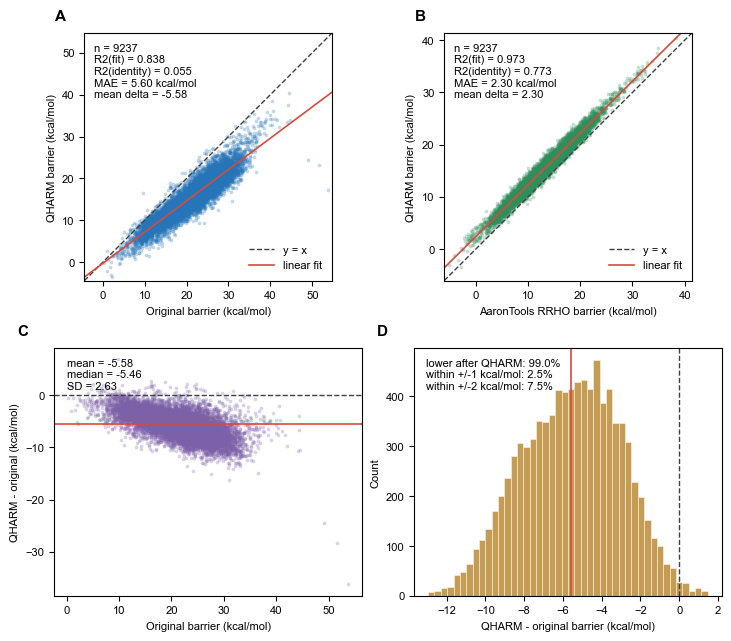

In [7]:
def metric_row(label):
    return metrics_df.loc[metrics_df["comparison"].eq(label)].iloc[0]


def scatter_panel(ax, x, y, xlabel, ylabel, label, color):
    d = comparison[[x, y]].dropna()
    xv = d[x].to_numpy()
    yv = d[y].to_numpy()
    ax.scatter(xv, yv, s=7, alpha=0.28, linewidths=0, color=color)
    lo = min(xv.min(), yv.min()) - 1
    hi = max(xv.max(), yv.max()) + 1
    ax.plot([lo, hi], [lo, hi], color="0.25", lw=1, ls="--", label="y = x")
    slope, intercept, *_ = stats.linregress(xv, yv)
    xx = np.array([lo, hi])
    ax.plot(xx, slope * xx + intercept, color="#d64b3c", lw=1.2, label="linear fit")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    m = metric_row(label)
    txt = (
        f"n = {int(m['n'])}\n"
        f"R2(fit) = {m['R2_linear_fit']:.3f}\n"
        f"R2(identity) = {m['R2_identity']:.3f}\n"
        f"MAE = {m['MAE_kcal_mol']:.2f} kcal/mol\n"
        f"mean delta = {m['mean_delta_kcal_mol']:.2f}"
    )
    ax.text(0.04, 0.96, txt, transform=ax.transAxes, va="top", ha="left")
    ax.legend(frameon=False, loc="lower right", handlelength=2.2)


fig, axes = plt.subplots(2, 2, figsize=(7.2, 6.3), constrained_layout=True)

scatter_panel(
    axes[0, 0],
    "barrier_kcal",
    "barrier_qharm_kcal",
    "Original barrier (kcal/mol)",
    "QHARM barrier (kcal/mol)",
    "Barrier: original DB -> QHARM",
    "#2675b8",
)
scatter_panel(
    axes[0, 1],
    "barrier_aarontools_rrho_kcal",
    "barrier_qharm_kcal",
    "AaronTools RRHO barrier (kcal/mol)",
    "QHARM barrier (kcal/mol)",
    "Barrier: AaronTools RRHO -> QHARM",
    "#2f8f5b",
)

axes[1, 0].scatter(
    comparison["barrier_kcal"],
    comparison["delta_barrier_qharm_vs_original"],
    s=7,
    alpha=0.28,
    linewidths=0,
    color="#7c60a8",
)
axes[1, 0].axhline(0, color="0.25", lw=1, ls="--")
axes[1, 0].axhline(comparison["delta_barrier_qharm_vs_original"].mean(), color="#d64b3c", lw=1.2)
axes[1, 0].set_xlabel("Original barrier (kcal/mol)")
axes[1, 0].set_ylabel("QHARM - original (kcal/mol)")
axes[1, 0].text(
    0.04,
    0.96,
    f"mean = {comparison['delta_barrier_qharm_vs_original'].mean():.2f}\n"
    f"median = {comparison['delta_barrier_qharm_vs_original'].median():.2f}\n"
    f"SD = {comparison['delta_barrier_qharm_vs_original'].std(ddof=1):.2f}",
    transform=axes[1, 0].transAxes,
    va="top",
    ha="left",
)

bins = np.linspace(
    comparison["delta_barrier_qharm_vs_original"].quantile(0.002),
    comparison["delta_barrier_qharm_vs_original"].quantile(0.998),
    45,
)
axes[1, 1].hist(
    comparison["delta_barrier_qharm_vs_original"],
    bins=bins,
    color="#b8872e",
    alpha=0.82,
    edgecolor="white",
    linewidth=0.4,
)
axes[1, 1].axvline(0, color="0.25", lw=1, ls="--")
axes[1, 1].axvline(comparison["delta_barrier_qharm_vs_original"].mean(), color="#d64b3c", lw=1.2)
axes[1, 1].set_xlabel("QHARM - original barrier (kcal/mol)")
axes[1, 1].set_ylabel("Count")
axes[1, 1].text(
    0.04,
    0.96,
    f"lower after QHARM: {(comparison['delta_barrier_qharm_vs_original'] < 0).mean() * 100:.1f}%\n"
    f"within +/-1 kcal/mol: {(comparison['delta_barrier_qharm_vs_original'].abs() <= 1).mean() * 100:.1f}%\n"
    f"within +/-2 kcal/mol: {(comparison['delta_barrier_qharm_vs_original'].abs() <= 2).mean() * 100:.1f}%",
    transform=axes[1, 1].transAxes,
    va="top",
    ha="left",
)

for ax, letter in zip(axes.flat, ["A", "B", "C", "D"]):
    ax.text(-0.12, 1.04, letter, transform=ax.transAxes, fontsize=11, fontweight="bold", va="bottom", ha="left")

fig.savefig(FIGURE_DIR / "Revision_QH_Barrier_Comparison.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTDIR / "qh_barrier_comparison_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

## Notes

The original database to QHARM comparison includes both the low-frequency treatment and the change from the released thermochemical values to AaronTools recomputation. The AaronTools RRHO to QHARM comparison isolates the low-frequency correction more directly.